# Customer Churn Analysis

## Integrated Assignment: SQL, Statistics, Machine Learning, and Professional Publishing

### Business Problem

Customer churn occurs when customers stop using a company's services. This project analyzes a telecommunications dataset to identify the characteristics associated with churn, build predictive machine-learning models, and recommend practical actions that may improve customer retention.

### Project Objectives

1. Query customer information using SQLite and SQL.
2. summarize customer behavior with descriptive statistics.
3. Test relationships between churn and selected customer characteristics.
4. Train and compare logistic regression, decision tree, and random forest models.
5. Translate the results into business recommendations.


In [6]:
import warnings
warnings.filterwarnings("ignore")

import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_URL = (
    "https://raw.githubusercontent.com/IBM/"
    "telco-customer-churn-on-icp4d/master/data/"
    "Telco-Customer-Churn.csv"
)

df = pd.read_csv(DATA_URL)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Preparation

The dataset is inspected for data types, missing values, blank strings, and duplicate records. `TotalCharges` is converted to numeric because blank entries may cause Pandas to initially treat it as text. Missing `TotalCharges` values are filled with the median.


In [7]:
df.info()

print("\nMissing values before cleaning:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

print("\nTarget distribution:")
display(df["Churn"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0



Duplicate rows: 0
Duplicate customer IDs: 0

Target distribution:


,count
Churn,
No,5174
Yes,1869


In [8]:
# Convert blank TotalCharges entries to missing values, then to numeric.
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(r"^\s*$", np.nan, regex=True),
    errors="coerce"
)

missing_total_charges = df["TotalCharges"].isna().sum()
total_charges_median = df["TotalCharges"].median()

print("Missing TotalCharges before filling:", missing_total_charges)
print("Median used:", round(total_charges_median, 2))

df["TotalCharges"] = df["TotalCharges"].fillna(total_charges_median)

# Standardize text columns by removing accidental spaces.
object_columns = df.select_dtypes(include="object").columns
df[object_columns] = df[object_columns].apply(lambda column: column.str.strip())

print("\nMissing values after cleaning:", df.isna().sum().sum())
display(df.head())


Missing TotalCharges before filling: 11
Median used: 1397.47

Missing values after cleaning: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df.to_csv("Telco-Customer-Churn-cleaned.csv", index=False)
print("Cleaned dataset saved.")


Cleaned dataset saved.


# Part 1: SQL Analysis

The cleaned CSV data is loaded into an SQLite database. Each required SQL query is then executed through Python, and its result is displayed as a Pandas DataFrame.


In [10]:
connection = sqlite3.connect("customer_churn.db")

# Replace the table each time this cell runs, preventing duplicate records.
df.to_sql("customers", connection, if_exists="replace", index=False)

table_check = pd.read_sql_query(
    "SELECT COUNT(*) AS rows_in_database FROM customers;",
    connection
)

display(table_check)


,rows_in_database
0,7043


In [11]:
queries = {
    "1. Total customers": """
        SELECT COUNT(*) AS total_customers
        FROM customers;
    """,

    "2. Churned customers": """
        SELECT COUNT(*) AS churned_customers
        FROM customers
        WHERE Churn = 'Yes';
    """,

    "3. Customers by gender": """
        SELECT gender, COUNT(*) AS customer_count
        FROM customers
        GROUP BY gender
        ORDER BY customer_count DESC;
    """,

    "4. Senior citizens": """
        SELECT COUNT(*) AS senior_citizens
        FROM customers
        WHERE SeniorCitizen = 1;
    """,

    "5. Average tenure by churn": """
        SELECT
            Churn,
            ROUND(AVG(tenure), 2) AS average_tenure
        FROM customers
        GROUP BY Churn;
    """,

    "6. Customers by contract type": """
        SELECT
            Contract,
            COUNT(*) AS customer_count
        FROM customers
        GROUP BY Contract
        ORDER BY customer_count DESC;
    """,

    "7. Average MonthlyCharges by InternetService": """
        SELECT
            InternetService,
            ROUND(AVG(MonthlyCharges), 2) AS average_monthly_charges
        FROM customers
        GROUP BY InternetService
        ORDER BY average_monthly_charges DESC;
    """,

    "8. Total TotalCharges by PaymentMethod": """
        SELECT
            PaymentMethod,
            ROUND(SUM(TotalCharges), 2) AS total_charges
        FROM customers
        GROUP BY PaymentMethod
        ORDER BY total_charges DESC;
    """,

    "9. Churn rate by contract type": """
        SELECT
            Contract,
            COUNT(*) AS total_customers,
            SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
            ROUND(
                100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
                / COUNT(*),
                2
            ) AS churn_rate_percent
        FROM customers
        GROUP BY Contract
        ORDER BY churn_rate_percent DESC;
    """,

    "10. Churn rate by InternetService": """
        SELECT
            InternetService,
            COUNT(*) AS total_customers,
            SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
            ROUND(
                100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
                / COUNT(*),
                2
            ) AS churn_rate_percent
        FROM customers
        GROUP BY InternetService
        ORDER BY churn_rate_percent DESC;
    """,

    "11. Churn rate by OnlineSecurity": """
        SELECT
            OnlineSecurity,
            COUNT(*) AS total_customers,
            SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
            ROUND(
                100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
                / COUNT(*),
                2
            ) AS churn_rate_percent
        FROM customers
        WHERE OnlineSecurity IN ('Yes', 'No')
        GROUP BY OnlineSecurity
        ORDER BY churn_rate_percent DESC;
    """,

    "12. Top five customer segments by churn rate": """
        SELECT
            Contract,
            InternetService,
            COUNT(*) AS total_customers,
            SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
            ROUND(
                100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
                / COUNT(*),
                2
            ) AS churn_rate_percent
        FROM customers
        GROUP BY Contract, InternetService
        ORDER BY churn_rate_percent DESC
        LIMIT 5;
    """
}


In [12]:
sql_results = {}

for query_name, sql in queries.items():
    print("\n" + "=" * 80)
    print(query_name)
    print("=" * 80)

    result = pd.read_sql_query(sql, connection)
    sql_results[query_name] = result
    display(result)



1. Total customers


,total_customers
0,7043



2. Churned customers


,churned_customers
0,1869



3. Customers by gender


...

,InternetService,total_customers,churned_customers,churn_rate_percent
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40



11. Churn rate by OnlineSecurity


,OnlineSecurity,total_customers,churned_customers,churn_rate_percent
0,No,3498,1461,41.77
1,Yes,2019,295,14.61



12. Top five customer segments by churn rate


,Contract,InternetService,total_customers,churned_customers,churn_rate_percent
0,Month-to-month,Fiber optic,2128,1162,54.61
1,Month-to-month,DSL,1223,394,32.22
2,One year,Fiber optic,539,104,19.29
3,Month-to-month,No,524,99,18.89
4,One year,DSL,570,53,9.30


In [13]:
sql_file_content = ""

for query_name, sql in queries.items():
    sql_file_content += f"-- {query_name}\n"
    sql_file_content += sql.strip() + "\n\n"

Path("queries.sql").write_text(sql_file_content, encoding="utf-8")

print("queries.sql created successfully.")
print("\nPreview:\n")
print(sql_file_content[:1500])


queries.sql created successfully.

Preview:

-- 1. Total customers
SELECT COUNT(*) AS total_customers
        FROM customers;

-- 2. Churned customers
SELECT COUNT(*) AS churned_customers
        FROM customers
        WHERE Churn = 'Yes';

-- 3. Customers by gender
SELECT gender, COUNT(*) AS customer_count
        FROM customers
        GROUP BY gender
        ORDER BY customer_count DESC;

-- 4. Senior citizens
SELECT COUNT(*) AS senior_citizens
        FROM customers
        WHERE SeniorCitizen = 1;

-- 5. Average tenure by churn
SELECT
            Churn,
            ROUND(AVG(tenure), 2) AS average_tenure
        FROM customers
        GROUP BY Churn;

-- 6. Customers by contract type
SELECT
            Contract,
            COUNT(*) AS customer_count
        FROM customers
        GROUP BY Contract
        ORDER BY customer_count DESC;

-- 7. Average MonthlyCharges by InternetService
SELECT
            InternetService,
            ROUND(AVG(MonthlyCharges), 2) AS average_monthly_c

In [14]:
from google.colab import files
files.download("queries.sql")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Part 2: Statistical Analysis and Hypothesis Testing

This section examines `tenure`, `MonthlyCharges`, and `TotalCharges` using descriptive statistics. It then applies a chi-square test and an independent-samples t-test.

A significance level of 0.05 is used. A p-value below 0.05 is treated as evidence against the null hypothesis.


In [15]:
numeric_variables = ["tenure", "MonthlyCharges", "TotalCharges"]

descriptive_statistics = pd.DataFrame({
    "Mean": df[numeric_variables].mean(),
    "Median": df[numeric_variables].median(),
    "Standard deviation": df[numeric_variables].std(),
    "Skewness": df[numeric_variables].skew(),
    "Minimum": df[numeric_variables].min(),
    "Maximum": df[numeric_variables].max()
}).round(2)

display(descriptive_statistics)


,Mean,Median,Standard deviation,Skewness,Minimum,Maximum
tenure,32.37,29.00,24.56,0.24,0.00,72.00
MonthlyCharges,64.76,70.35,30.09,-0.22,18.25,118.75
TotalCharges,2281.92,1397.48,2265.27,0.96,18.80,8684.80


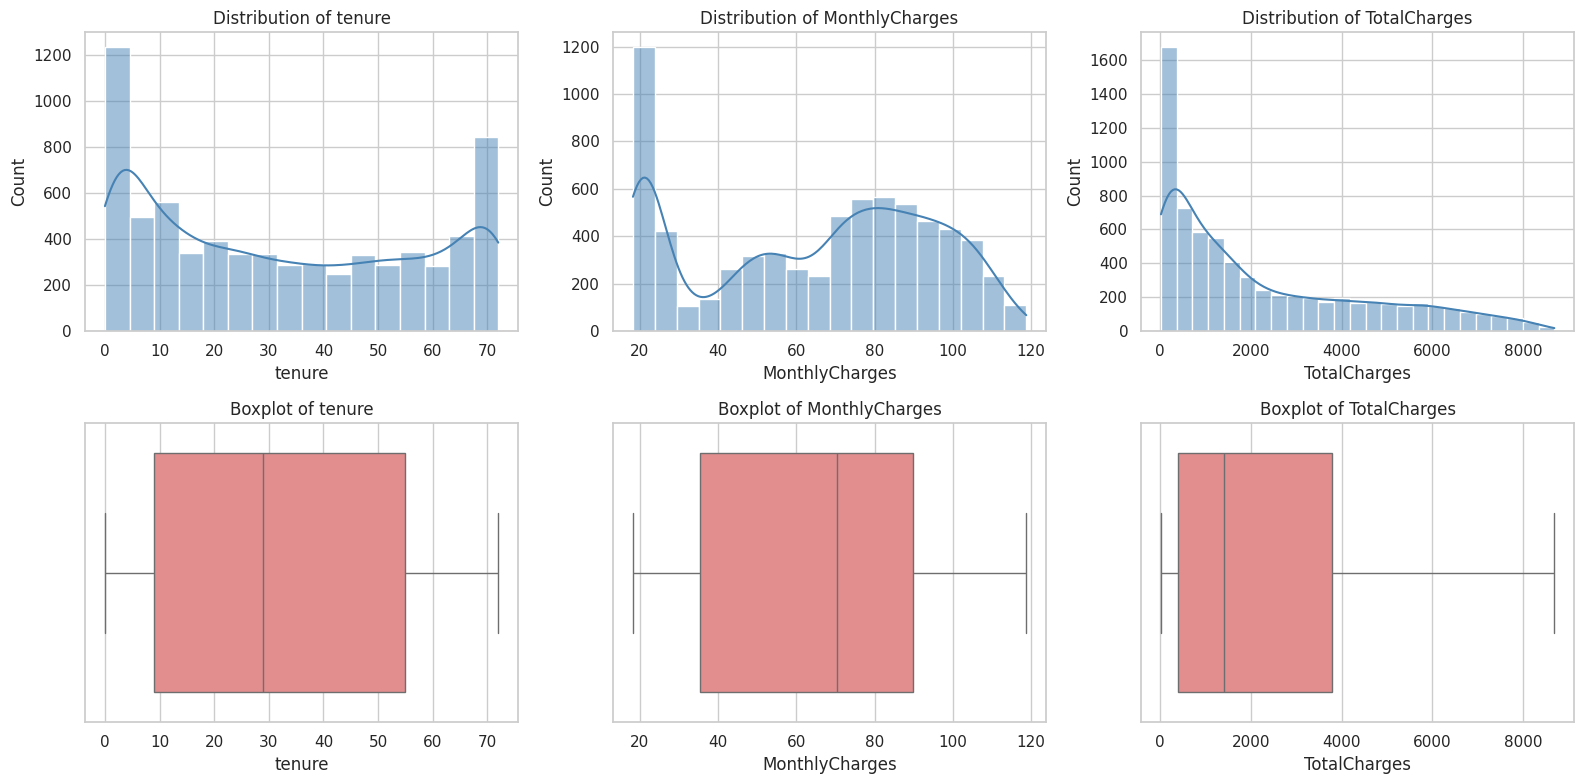

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for index, variable in enumerate(numeric_variables):
    sns.histplot(df[variable], kde=True, ax=axes[0, index], color="steelblue")
    axes[0, index].set_title(f"Distribution of {variable}")

    sns.boxplot(x=df[variable], ax=axes[1, index], color="lightcoral")
    axes[1, index].set_title(f"Boxplot of {variable}")

plt.tight_layout()
plt.show()


In [17]:
for variable in numeric_variables:
    skewness = df[variable].skew()

    if skewness > 1:
        shape = "strongly right-skewed"
    elif skewness > 0.5:
        shape = "moderately right-skewed"
    elif skewness < -1:
        shape = "strongly left-skewed"
    elif skewness < -0.5:
        shape = "moderately left-skewed"
    else:
        shape = "approximately symmetric"

    q1 = df[variable].quantile(0.25)
    q3 = df[variable].quantile(0.75)
    iqr = q3 - q1
    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = (
        (df[variable] < lower_limit) |
        (df[variable] > upper_limit)
    ).sum()

    print(
        f"{variable}: {shape}; "
        f"{outlier_count} observations lie outside the 1.5-IQR limits."
    )


tenure: approximately symmetric; 0 observations lie outside the 1.5-IQR limits.
MonthlyCharges: approximately symmetric; 0 observations lie outside the 1.5-IQR limits.
TotalCharges: moderately right-skewed; 0 observations lie outside the 1.5-IQR limits.


### Descriptive Statistics Interpretation

- **Tenure:** The mean and median indicate the typical length of the customer relationship. Its skewness and boxplot show whether customers are concentrated at shorter or longer tenures.
- **MonthlyCharges:** The distribution shows the range of monthly customer bills and whether unusually high or low charges are present.
- **TotalCharges:** This variable is influenced by both tenure and monthly charges. A mean noticeably above the median and positive skewness indicate a right-skewed distribution.
- **Outliers:** Values outside the 1.5-IQR limits were reviewed. They were not automatically removed because high charges and long customer relationships may be valid business observations rather than data-entry errors.


In [18]:
contract_churn_table = pd.crosstab(df["Contract"], df["Churn"])
display(contract_churn_table)

chi2_statistic, chi2_p_value, degrees_of_freedom, expected_counts = (
    chi2_contingency(contract_churn_table)
)

expected_table = pd.DataFrame(
    expected_counts,
    index=contract_churn_table.index,
    columns=contract_churn_table.columns
)

print(f"Chi-square statistic: {chi2_statistic:.4f}")
print(f"Degrees of freedom: {degrees_of_freedom}")
print(f"P-value: {chi2_p_value:.6g}")
print(f"Minimum expected cell count: {expected_counts.min():.2f}")

print("\nExpected counts:")
display(expected_table.round(2))

if chi2_p_value < 0.05:
    print(
        "Conclusion: Reject the null hypothesis. "
        "There is a statistically significant association "
        "between Contract and Churn."
    )
else:
    print(
        "Conclusion: Fail to reject the null hypothesis. "
        "The test does not provide sufficient evidence of an "
        "association between Contract and Churn."
    )


Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


Chi-square statistic: 1184.5966
Degrees of freedom: 2
P-value: 5.86304e-258
Minimum expected cell count: 390.89

Expected counts:


Churn,No,Yes
Contract,,
Month-to-month,2846.69,1028.31
One year,1082.11,390.89
Two year,1245.20,449.80


Conclusion: Reject the null hypothesis. There is a statistically significant association between Contract and Churn.


In [19]:
churned_monthly_charges = df.loc[
    df["Churn"] == "Yes", "MonthlyCharges"
].dropna()

retained_monthly_charges = df.loc[
    df["Churn"] == "No", "MonthlyCharges"
].dropna()

t_statistic, t_p_value = ttest_ind(
    churned_monthly_charges,
    retained_monthly_charges,
    equal_var=False
)

monthly_group_summary = df.groupby("Churn")["MonthlyCharges"].agg(
    ["count", "mean", "median", "std"]
).round(2)

display(monthly_group_summary)

print(f"Welch's t-statistic: {t_statistic:.4f}")
print(f"P-value: {t_p_value:.6g}")

if t_p_value < 0.05:
    print(
        "Conclusion: Reject the null hypothesis. "
        "The mean MonthlyCharges differ significantly between "
        "churned and non-churned customers."
    )
else:
    print(
        "Conclusion: Fail to reject the null hypothesis. "
        "There is insufficient evidence of a difference in mean "
        "MonthlyCharges between the two groups."
    )


,count,mean,median,std
Churn,,,,
No,5174,61.27,64.43,31.09
Yes,1869,74.44,79.65,24.67


Welch's t-statistic: 18.4075
P-value: 8.59245e-73
Conclusion: Reject the null hypothesis. The mean MonthlyCharges differ significantly between churned and non-churned customers.


### Statistical Interpretation and Business Recommendation

The chi-square test produced a p-value below 0.05, so the null hypothesis of independence was rejected. This indicates that contract type and churn have a statistically significant association. Statistical significance does not by itself prove that contract type causes churn.

Welch's independent-samples t-test compared average monthly charges for churned and retained customers. The reported p-value should be interpreted against the 0.05 significance level. The group means show the direction and practical size of the difference.

**Business recommendation:** The company should prioritize month-to-month customers in retention campaigns and test incentives that encourage movement to longer contracts. Customers with high monthly charges should also receive proactive plan reviews, especially when they are new or do not use support and security services.


# Part 3: Machine Learning

The target variable `Churn` is mapped from Yes/No to 1/0. `customerID` is removed because it is only an identifier. The dataset is split into 80% training data and 20% testing data using stratification so both sets retain a similar churn proportion.

Categorical variables are one-hot encoded. Numeric variables are median-imputed and standardized for logistic regression. Preprocessing is fitted only on training data to prevent data leakage.


In [20]:
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).rename("proportion"))


Training shape: (5634, 19)
Testing shape: (1409, 19)
Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Training target distribution:


,proportion
Churn,
0,0.734647
1,0.265353


In [21]:
numeric_transformer_scaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

numeric_transformer_unscaled = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_scaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_unscaled, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [22]:
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", scaled_preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

models = {
    "Logistic Regression": logistic_pipeline,
    "Decision Tree": decision_tree_pipeline,
    "Random Forest": random_forest_pipeline
}


In [23]:
model_metrics = []
predictions = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[model_name] = y_pred

    model_metrics.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0)
    })

metrics_df = (
    pd.DataFrame(model_metrics)
    .set_index("Model")
    .sort_values("F1", ascending=False)
)

display(metrics_df.round(4))


,Accuracy,Precision,Recall,F1
Model,,,,
Logistic Regression,0.8055,0.6572,0.5588,0.6040
Decision Tree,0.7921,0.6576,0.4519,0.5357
Random Forest,0.7779,0.6034,0.4759,0.5321


In [24]:
for model_name, y_pred in predictions.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


Decision Tree
              precision    recall  f1-score   support

    No Churn       0.82      0.91      0.87      1035
       Churn       0.66      0.45      0.54       374

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409


Random Forest
              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.85      1035
       Churn       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77

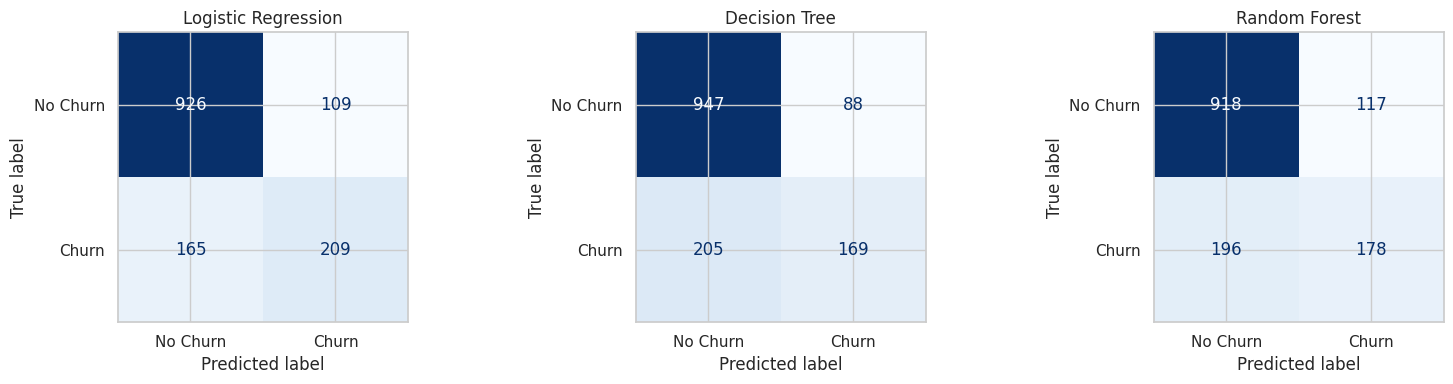

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for axis, (model_name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["No Churn", "Churn"],
        cmap="Blues",
        colorbar=False,
        ax=axis
    )
    axis.set_title(model_name)

plt.tight_layout()
plt.show()


,Feature,Importance
3,TotalCharges,0.1627
1,tenure,0.1372
2,MonthlyCharges,0.1364
36,Contract_Month-to-month,0.0478
18,OnlineSecurity_No,0.0332
43,PaymentMethod_Electronic check,0.0326
16,InternetService_Fiber optic,0.0299
27,TechSupport_No,0.0247
0,SeniorCitizen,0.0197
21,OnlineBackup_No,0.0183


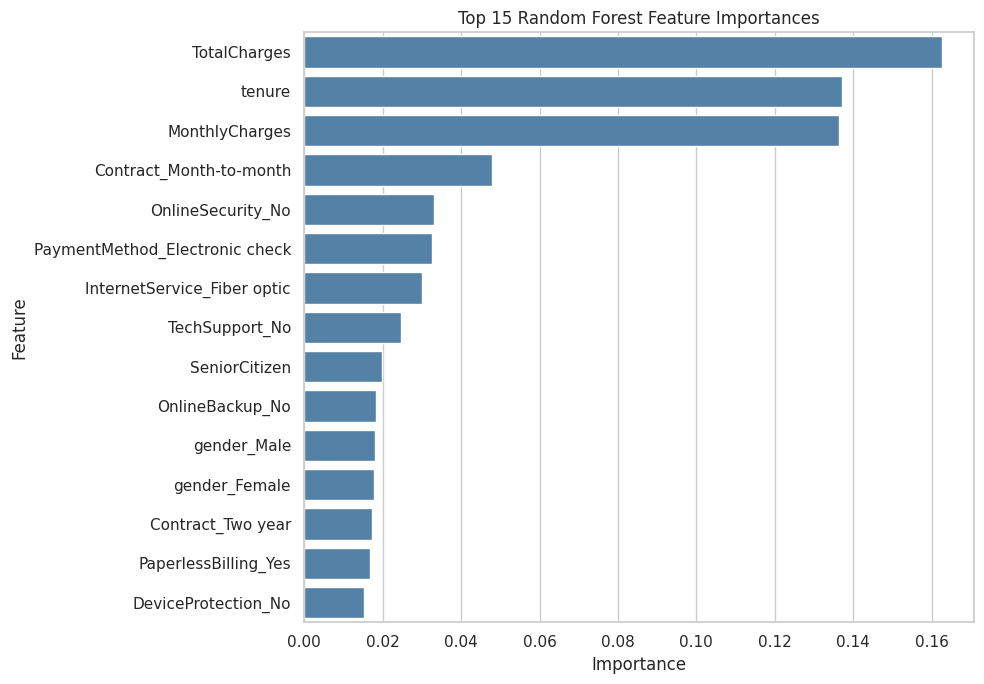

In [26]:
rf_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
rf_model = random_forest_pipeline.named_steps["model"]

encoded_feature_names = rf_preprocessor.get_feature_names_out()

feature_importance = (
    pd.DataFrame({
        "Feature": encoded_feature_names,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

# Remove pipeline prefixes for cleaner labels.
feature_importance["Feature"] = (
    feature_importance["Feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

display(feature_importance.round(4))

plt.figure(figsize=(10, 7))
sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    color="steelblue"
)
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [27]:
best_accuracy_model = metrics_df["Accuracy"].idxmax()
best_f1_model = metrics_df["F1"].idxmax()

print(
    f"Highest test accuracy: {best_accuracy_model} "
    f"({metrics_df.loc[best_accuracy_model, 'Accuracy']:.3f})"
)

print(
    f"Highest test F1 score: {best_f1_model} "
    f"({metrics_df.loc[best_f1_model, 'F1']:.3f})"
)

print("\nTop five Random Forest features:")
display(feature_importance.head(5))


Highest test accuracy: Logistic Regression (0.806)
Highest test F1 score: Logistic Regression (0.604)

Top five Random Forest features:


,Feature,Importance
3,TotalCharges,0.162669
1,tenure,0.137204
2,MonthlyCharges,0.136437
36,Contract_Month-to-month,0.047818
18,OnlineSecurity_No,0.033157


## Model Interpretation

The three models were evaluated on the same unseen test set. **[MODEL NAME]** achieved the highest test accuracy of **[VALUE]**, while **[MODEL NAME]** achieved the highest F1 score of **[VALUE]**. F1 and recall are especially useful here because failing to detect a likely churner can represent a lost retention opportunity.

The Random Forest importance chart indicates that **[LIST IMPORTANT FEATURES FROM THE CHART]** contributed strongly to its predictions. These results align with the SQL and statistical analysis where contract type, tenure, charges, internet service, and support-related services showed meaningful churn patterns.

Feature importance indicates predictive usefulness rather than causation. Therefore, retention actions based on the model should first be evaluated through controlled business experiments.

## Final Business Recommendations

1. **Prioritize high-risk customers:** Score active customers regularly and contact those with the highest predicted churn probabilities before they cancel.
2. **Target month-to-month customers:** Test discounts, loyalty benefits, or flexible incentives that encourage longer contracts.
3. **Improve early-tenure support:** Provide proactive onboarding and check-ins during the first months of the customer relationship.
4. **Review high-cost plans:** Contact high-risk customers with high monthly charges and recommend better-matched plans.
5. **Promote security and support services:** Offer relevant support or security packages to customers who lack them.
6. **Measure results:** Run controlled trials and track churn reduction, retention cost, and customer lifetime value before rolling a campaign out widely.


# Conclusion

This project combined SQL, statistical testing, and machine learning to investigate telecommunications customer churn. SQL identified churn differences across customer groups, while hypothesis testing evaluated whether selected relationships were statistically significant. The machine-learning models demonstrated that customer characteristics can be used to estimate churn risk.

The most useful business application is not simply predicting churn, but using predictions to prioritize practical retention interventions. Contract incentives, early-tenure support, plan reviews, and service improvements should be tested with controlled experiments to determine whether they produce a meaningful reduction in churn.


In [28]:
connection.close()
print("SQLite connection closed.")


SQLite connection closed.
